# Lab 01-2 - $k$-means clustering

**Directions**: 
* Record your responses to all embedded questions in this Jupyter Notebook
* In the top-right corner of the notebook, click **Select Kernel**. Choose **Python Environments...**, then select the Anaconda `base` environment (it should be listed automatically since Anaconda was installed in Step 2).
* Run the first code cell (click the ▶ play button to its left, or press `Shift+Enter`). VS Code may prompt you to install the `ipykernel` package the first time — click **Install** and wait for it to finish.
* Continue running cells top to bottom with `Shift+Enter` to work through the lab.
* You can add code and markdown cells just like you would for `.Rmd` and `.qmd` files by clicking the appropriate button in the menu above.

In [58]:
import numpy as np 
import matplotlib.pyplot as plt

## Part 1 - $k$-means clustering

$k$-means clustering, along with many other machine learning tools that we'll make extensive use of, is implemented in the `sklearn` or "scikit-learn" library:

In [59]:
import sklearn
from sklearn.cluster import KMeans # Import k-means function
import warnings
warnings.filterwarnings("ignore") ## We will turn off warnings since k-means will warn about future changes

This portion of the lab will explore $k$-means clustering and related concepts on two simulated data sets that exhibit very different patterns:

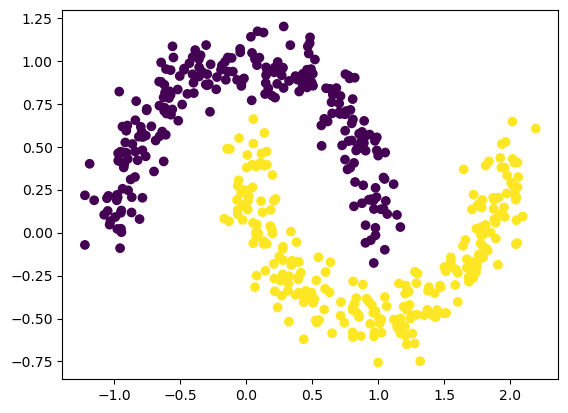

In [60]:
## Datasets module
from sklearn import datasets

## Dataset #1 - "moons"
moons = datasets.make_moons(n_samples=500, noise=0.11, random_state=8)
moons_X = moons[0]         # features to use in clustering
moons_labels = moons[1]    # true cluster identities

## Visualization
plt.scatter(moons_X[:,0], moons_X[:,1], c =moons_labels)
plt.show()

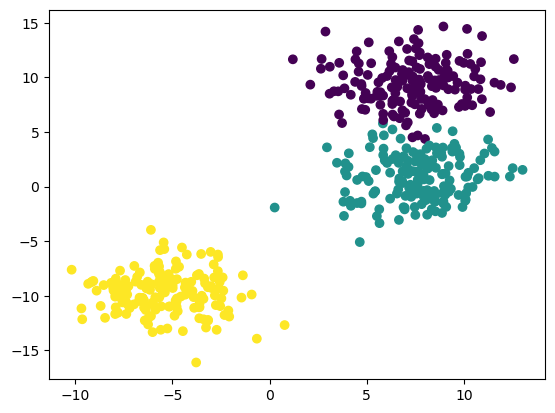

In [61]:
## Dataset #2 - "blobs"
blobs = datasets.make_blobs(n_samples=500, cluster_std=2, random_state=8)
blobs_X = blobs[0]         # features to use in clustering
blobs_labels = blobs[1]    # true cluster identities

plt.scatter(blobs_X[:,0], blobs_X[:,1], c = blobs_labels)
plt.show()

### Preprocessing

In most applications the data you receive are not immediately ready to be input directly into machine learning algorithms. Instead, additional steps known as *preprocessing* are typically applied before machine algorithms are used.

Because $k$-means clustering relies upon distances between data-points and cluster prototypes, the unit scale of each feature is influential.

- Humans know that heights of 70 inches vs. 58 inches (12 inches apart) and 6 ft vs. 5 (1 foot apart) are equally far from each other
- In the $k$-means algorithm, without standardization, a variable expressed in inches will exert more influence than an identical variable expressed in feet.
- An easy way to equalize the influence of features with different scales is to standardize them via the `StandardScaler()` function in `sklearn`, which applies a $Z$-score transformation to each feature:

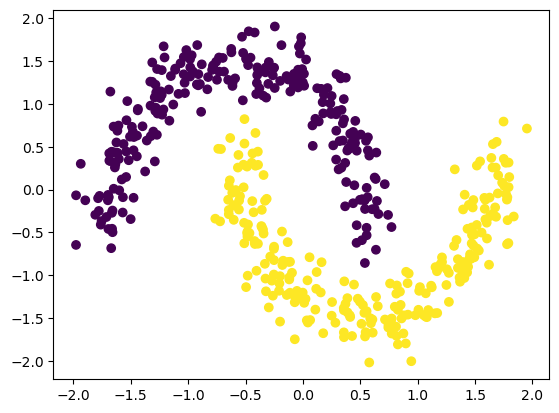

In [62]:
from sklearn.preprocessing import StandardScaler
moons_XS = StandardScaler().fit_transform(moons_X) # use the fit_transform method of a newly instantiated StandardScaler object

## Plot the standardized features, notice the subtle change in the x/y axes
plt.scatter(moons_XS[:,0], moons_XS[:,1], c =moons_labels) 

### Choosing $k$

The $k$-means algorithm requires $k$ be pre-specified. A simple strategy to help select an appropriate number of clusters is to search over a range of possible values of $k$ to find the point where the rate of improvement in the clustering objective function begins to diminish. You should note that the objective function will always improve as $k$ increases, so we are not looking for a minimum. Instead, we are looking for an inflection point or "elbow" in the curve produced by the loop given below.

Also note that since the initial location of the $k$ cluster centers are random, we set `random_state=8` random number generator seed value for reproducible randomness. 

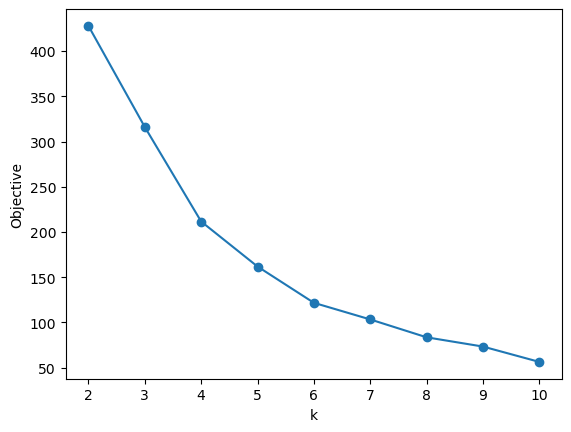

In [63]:
## Loop through choices of k ranging from 2 to 10
scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=8)
    kmeans.fit(moons_XS)
    scores.append(kmeans.inertia_)

## Visualize
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("k")
plt.ylabel("Objective")
plt.show()

For the `moons` data we see that this curve shows an inflection point (or elbow) around $k=4$ or $k=5$, suggesting we use that many clusters in our final analysis of these data.

### Evaluating cluster fit

**Silhouette scores** provide a method for validating clustering performance. Recall that each data-point's silhouette is a ratio of its difference in mean pairwise distance between points in the nearest neighboring clustering and its mean pairwise distance between points in assigned cluster divided by the larger of these two means.

A silhouette score approaching +1 indicates that a data-point is substantially closer to the data in its assigned cluster than it is to data in the neighboring clustering, a silhouette score of 0 indicates it is equally close, and a negative silhouette score indicates the point is on average closer to the members of a different cluster than the one it was assigned to.

The *mean silhouette score* across all data-points can be used to summarize the clustering performance of your chosen algorithm. To calculate silhouette scores we can use the `silhouette score()` function in the `metrics` module of `sklearn`: 

In [64]:
from sklearn.metrics import silhouette_score
my_clusters = KMeans(n_clusters=4, random_state=8)   # init the k-means object

## Calculate silhouette scores
my_sils = silhouette_score(moons_XS, my_clusters.fit_predict(moons_XS))

## Mean sil score
np.average(my_sils)

np.float64(0.42136329202499995)

An average silhouette score of 0.42 indicates modest to weak performance. In generally, average silhouette scores between 0.25 and 0.5 indicate weak but potentially meaningful clustering, averages between 0.5 and 0.7 indicate moderate to strong clustering, and values above 0.7 indicate excellent performance.  The weak performance of $k$-means for these data should be apparent when graphing the clustering results for $k=4$:

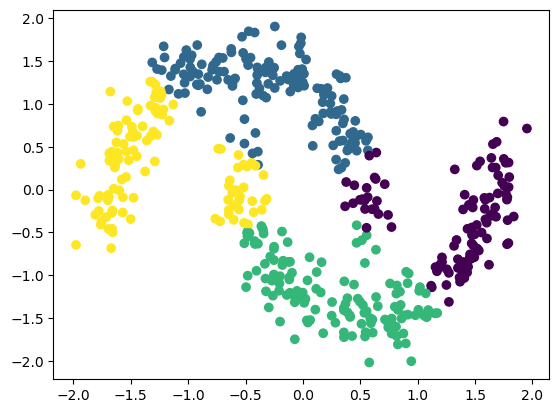

In [65]:
plt.scatter(moons_XS[:,0], moons_XS[:,1], c =my_clusters.predict(moons_XS)) 
plt.show()

Before moving on to answer the question that appears below, I encourage you to skim over the [KMeans documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) provided by `sklearn`.  Here you can find information not covered in this lab, such as how to find the coordinates of the cluster prototypes or change the $k$-means initialization algorithm that is being used.

**Question 1**: Earlier in this section we introduced a second simulated data set named `blobs`. Using this data set, perform a clustering analysis that includes the following steps:

- a) Proper pre-processing of the data to account for possible differences in scaling.
- b) Appropriate selection of $k$.
- c) Use of Silhouette scores to evaluate clustering fit.
- d) Visualization of the final clustering results.

In addition to providing code that accomplishes each step, provide a 3-4 sentence written summary of your methods and results using a professional scientific tone and an appropriate level of detail. In your summary you should clearly summarize the steps you used and how you interpret the success of the method.

**Question 1 Written Summary :**


To account for difference in feature scale, we standardized the dataset using z-score normalization. Plotting the blop_pr data set after standardising reveals a much smaller scale. We fit K-Means models for k = 2 through k = 10 and evaluated the resulting inertia, identifying an elbow point at 
k = 3. This choice was supported by silhouette analysis where k = 3 yielded a high average silhouette score (0.63) compared to k = 4 average silhouette score (0.48). These results are consistent with the data's structure of 3 distinct blobs supporting k = 3 as the best clustering solution.
 

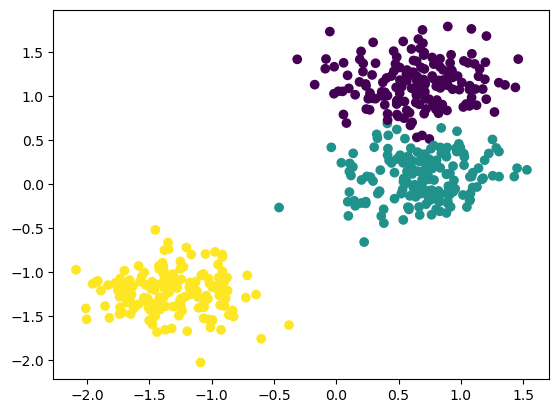

In [66]:
# Write your code here
# Pre process the blob data set using StandardScaler
blob_pr = StandardScaler().fit_transform(blobs_X)
plt.scatter(blob_pr[:,0], blob_pr[:,1], c = blobs_labels) 


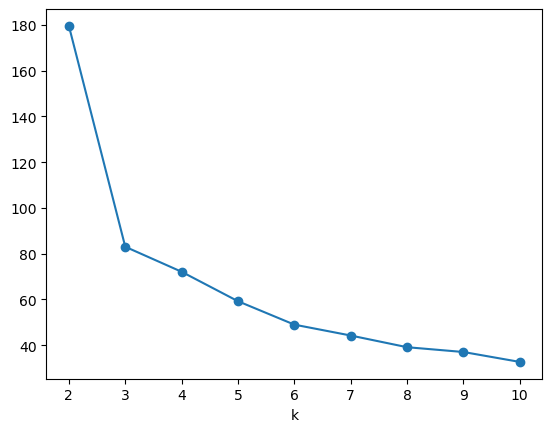

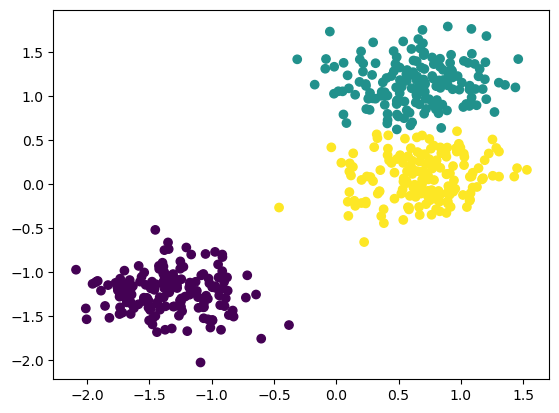

In [79]:
# Choosing the best k for the blob data set

k_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 8)
    kmeans.fit(blob_pr)
    k_scores.append(kmeans.inertia_)

plt.plot(range(2,11),k_scores,marker ='o')
plt.xlabel("k")
plt.show()

# Using the silhoutte score to evaluate clustering fit for the blob data set
my_clusters = KMeans(n_clusters = 3, random_state = 8)
sils_score = silhouette_score(blob_pr, my_clusters.fit_predict(blob_pr))
np.average(sils_score)

plt.scatter(blob_pr[:,0], blob_pr[:,1], c =my_clusters.predict(blob_pr)) 
plt.show()

## Part 2 - Application of $k$-means - image segmentation

Image segmentation is the process of dividing an image into collections of pixels that are labeled by "masks". There are many approaches to image segmentation, but for a variety of applications simple $k$-means clustering can work surprisingly well.

The code below reads an image from the web and then displays it using functions contained in the `skimage` library:

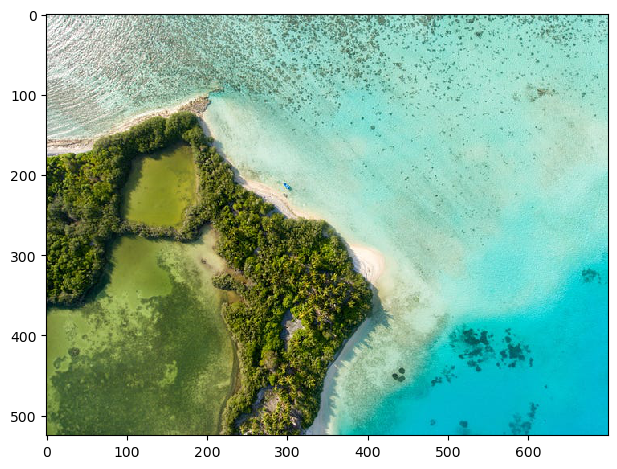

In [68]:
from skimage import io
my_img = io.imread("../images/beach_img.jpg") # ../ means go one directory up
io.imshow(my_img)
io.show()

To begin, you should notice that the image is stored in a 3-d array:

In [69]:
my_img.shape

(525, 700, 3)

The first two dimensions of this array define a pixel location, while the third dimension define a pixel's the color channel values under the [RGB color model](https://en.wikipedia.org/wiki/RGB_color_model). Thus, each element in the array is a pixel intensity in the respective color channel, with values ranging from 0 to 255.

To apply $k$-means clustering we'll need to reshape the image into a 2-d array where the first axis of the array (ie: rows) represents the pixel and the second axis (ie: columns) represents the color channel.  This is because we'd like to cluster all pixels, regardless of their location, based upon their color intensities.

The code below accomplishes this using `reshape()`:

In [70]:
my_img_2d = my_img.reshape(my_img.shape[0]*my_img.shape[1], my_img.shape[2])

While we'll rely upon the data to guide our choice of $k$ in many clustering applications, in image segmentation we might choose $k$ ourselves using domain-specific knowledge and goals.

For example, we might choose $k=2$ if our goal is to separate water from land:

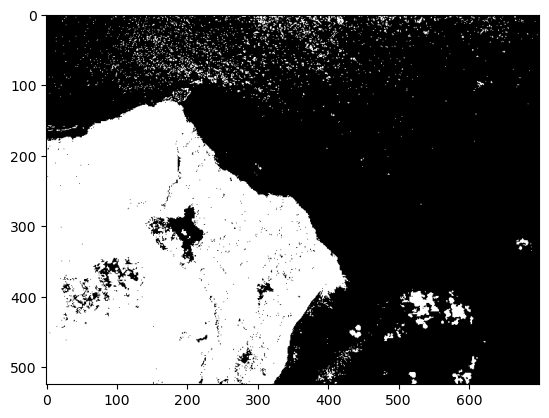

In [71]:
kmeans_fit = KMeans(n_clusters=2, random_state=10, n_init=10).fit(my_img_2d)
plt.imshow(kmeans_fit.labels_.reshape(525,700).astype(int), cmap='gray')

Alternatively, we can see that choosing $k=3$ will further segment the water to label a shallower sandy section and a deep water section.

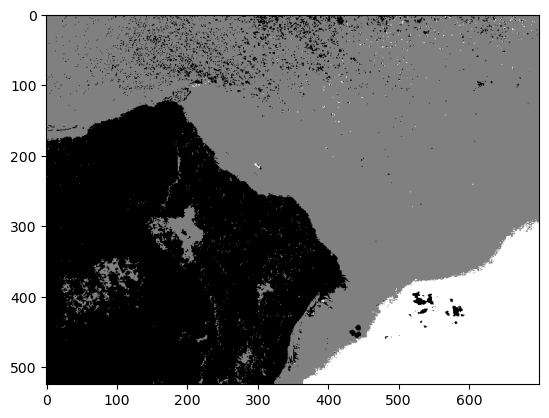

In [72]:
from sklearn.cluster import KMeans
kmeans_fit = KMeans(n_clusters=3, random_state=10, n_init=10).fit(my_img_2d)
plt.imshow(kmeans_fit.labels_.reshape(525,700).astype(int), cmap='gray')

While this approach isn't perfect, especially compared to more modern image segmentation approaches, the fact that $k$-means is simple, efficient, and doesn't require extensive training or tuning make it an attractive option.

**Question 2**: The aim of this question is for you to perform your own image segmentation using $k$-means and practice describing your methodology and results using an appropriate scientific tone. To receive full credit, your submitted response must include the following steps:

1. Locate an image on the web (or anywhere else) that you believe is appropriate for segmentation. You are welcome to try an image from the "cats" data folder that was provided in the lab section on looping.
2. Read your chosen image into Python (either directly from the web or from a local directory).
3. Use $k$-means clustering with a meaningful choice of $k$ to segment the image. Pay careful attention to the color channels in your image, as not every image you find on the web will be stored using the RGB color model.
4. Report your methods and results in a short paragraph (at least 4 sentences, written in a scientific tone). Your paragraph should explicitly address:
   - Why you chose your particular value of $k$ (e.g., domain knowledge about how many segments you expected, or an elbow/silhouette analysis).
   - What visual feature(s) — color, texture, brightness — the clustering appears to be grouping pixels by.
   - Whether each resulting segment corresponds to a semantically meaningful region of the image (e.g., "sky," "water," "fur"), or whether the segmentation mixes unrelated regions together.
   - One limitation of applying $k$-means specifically (as opposed to a more modern segmentation method) to your chosen image.

   Include visuals of both the original and segmented images to support your discussion.

**Question 2 Written Summary:** 


Using domain specific knowledge to reflect the 3 different shades of the cat's fur and the background, we settled for  k = 4 clusters. Clustering appears to be grouping pixels by color brightness i.e darker tones together, lighter tones together. This, however, results in unrelated regions like the cat's fur and the background of the image being clustered together. This reveals a limitation of using k-means in segmentation where it uses pixel-level color intensity without contextual awareness. Overall, while k = 4 clusters matched our expected color groupings of the cat's fur, the results did not reflect the distinct objects in the image.

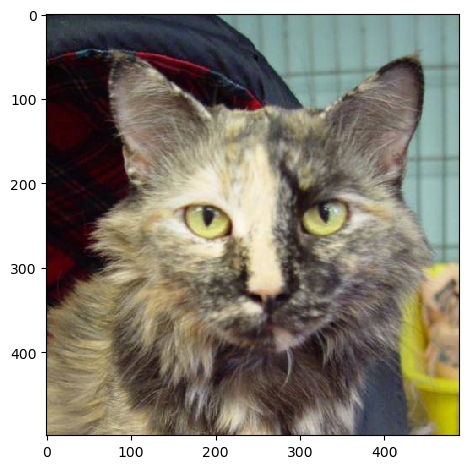

In [73]:
# Write your code here
# Read cat image into python and display it
cat_img = io.imread("../data/cats/cat.10.jpg") 
io.imshow(cat_img)
io.show()

In [74]:
# Display shape of cat image
cat_img.shape

(499, 489, 3)

In [75]:
# Reshape the cat image into a 2D array
cat_img2d = cat_img.reshape(cat_img.shape[0]*cat_img.shape[1], cat_img.shape[2])

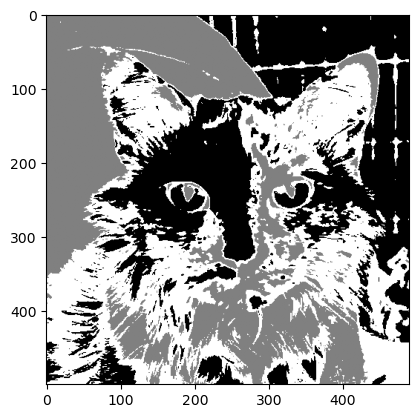

In [76]:
# Testing k-means clustering on the cat image

kmeans_fit = KMeans(n_clusters= 3, random_state=10, n_init=10).fit(cat_img2d)
plt.imshow(kmeans_fit.labels_.reshape(499,489).astype(int), cmap='gray')

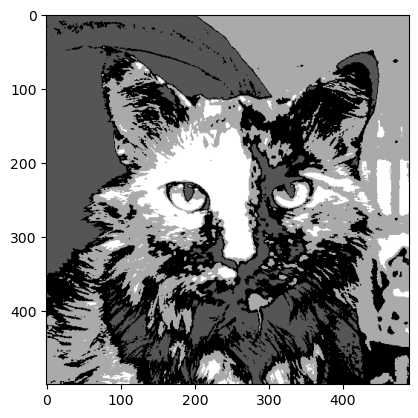

In [77]:
kmeans_fit = KMeans(n_clusters= 4, random_state=10, n_init=10).fit(cat_img2d)
plt.imshow(kmeans_fit.labels_.reshape(499,489).astype(int), cmap='gray')